In [1]:
import psutil
import platform
import os
env_name = os.environ.get('CONDA_DEFAULT_ENV')
print("当前 conda 环境名：", env_name)
print(platform.system()) # 操作系统名称
print(platform.release()) # 操作系统版本
print(platform.machine()) # 计算机架构
print(platform.processor()) # 处理器类型
# CPU 信息
print(psutil.cpu_count()) # CPU 核数
print(psutil.cpu_freq()) # CPU 频率
# 内存信息
print(psutil.virtual_memory()) # 内存总量、可用内存、已用内存等

当前 conda 环境名： xixi22
Windows
11
AMD64
AMD64 Family 25 Model 117 Stepping 2, AuthenticAMD
16
scpufreq(current=2499.0, min=0.0, max=3801.0)
svmem(total=29797376000, available=8315486208, percent=72.1, used=21481889792, free=8315486208)


一、序列模型  

1.1 理论计算题

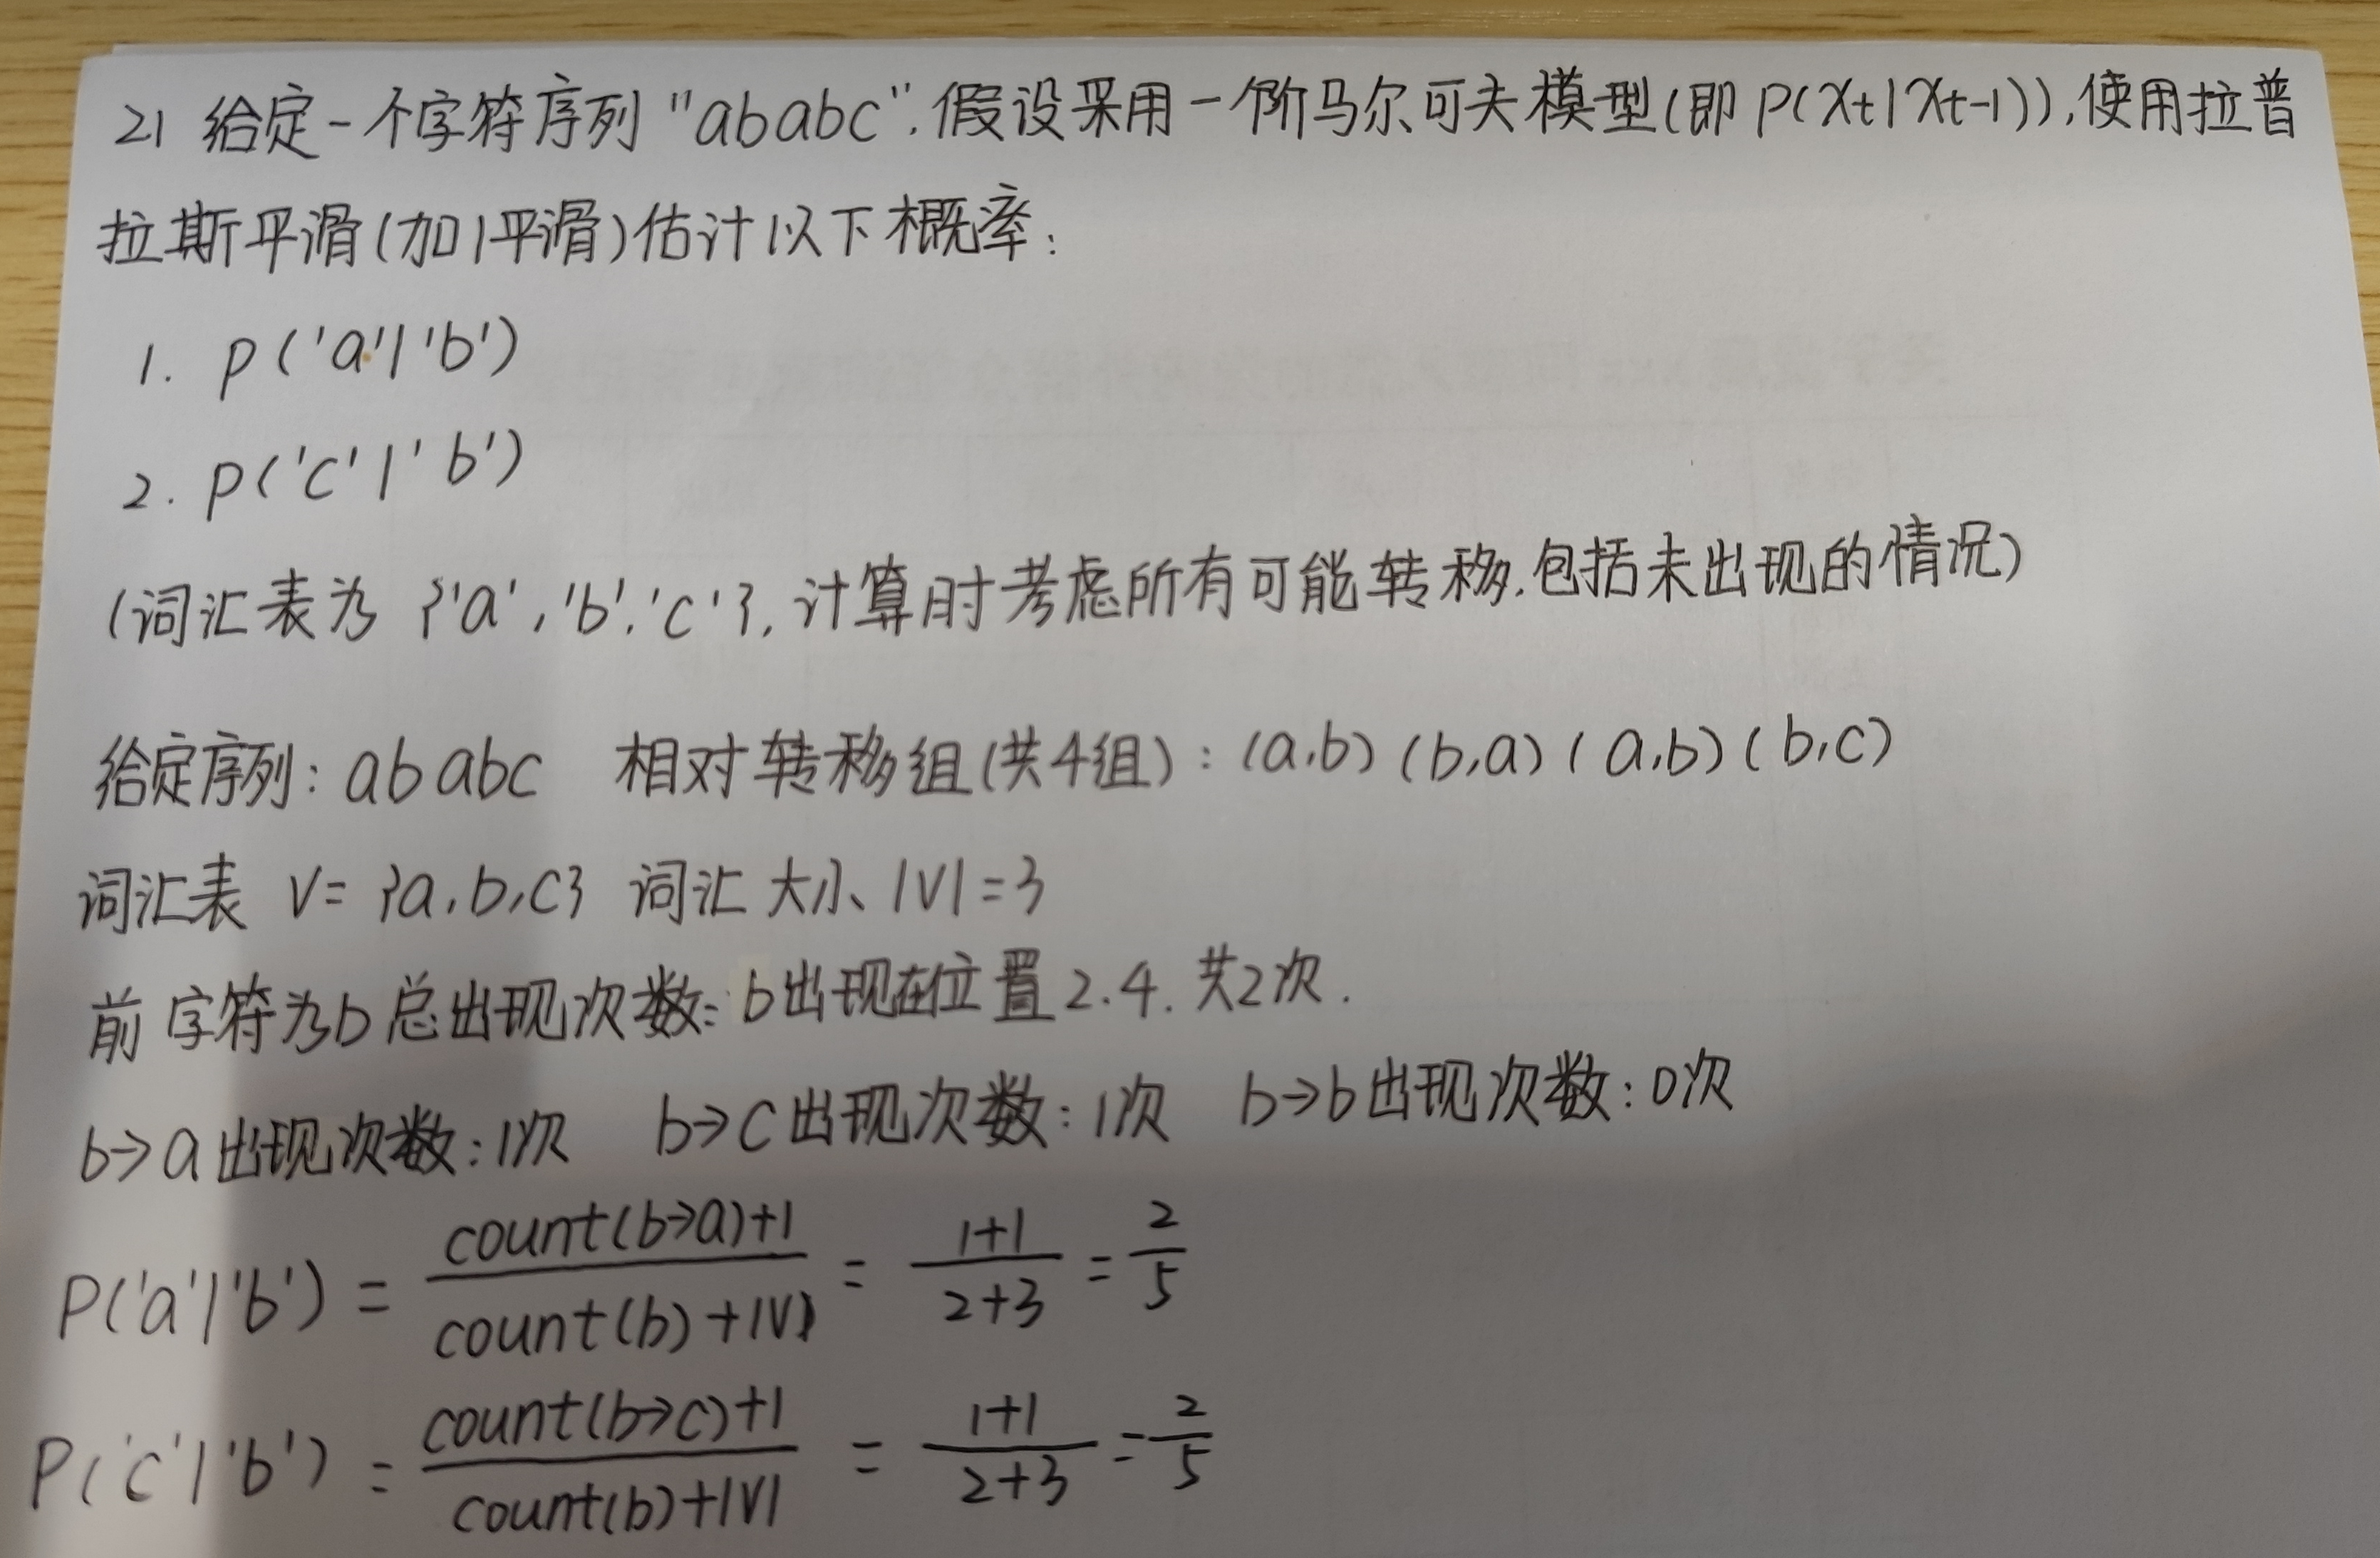

1.2 编程题   
&emsp;&emsp;编写一个函数preprocess_text(text,n)，完成以下步骤：  
&emsp;&emsp;1、将文本转换为小写，去除标点符号（保留字母和空格）。  
&emsp;&emsp;2、按空格分词。  
&emsp;&emsp;3、构建词汇表（按出现频率排序，分配整数ID，从0开始）。  
&emsp;&emsp;4、用滑动窗口生成长度为n的特征序列和对应的下一个词标签（用于自回归语言模型）。  
&emsp;&emsp;返回词汇表字典和（特征列表，标签列表）。例如，输入"The time machine"和n=2，应生成特征[['the','time'],['time','machine']]和标签['machine',None]（若无后续词则忽略）。

In [6]:
import re
from collections import Counter

def preprocess_text(text, n):
    # 1、转小写、去除标点 
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)   # 只保留字母和空格
    print("预处理后的文本：")
    print(text)

    # 2、按空格分词
    words = text.split()
    print("\n分词结果：")
    print(words)

    # 3、构建词汇表
    word_count = Counter(words)

    # 按出现频率降序排序；频率相同按字母顺序排序
    sorted_words = sorted(word_count.items(),
                          key=lambda x: (-x[1], x[0]))

    vocab = {}
    for idx, (word, count) in enumerate(sorted_words):
        vocab[word] = idx

    print("\n词频统计：")
    print(word_count)

    print("\n词汇表（word -> id）：")
    print(vocab)

    # 第4、滑动窗口生成特征和标签
    features = []
    labels = []

    for i in range(len(words) - n + 1):
        feature = words[i:i+n]

        # 判断是否有下一个词
        if i + n < len(words):
            label = words[i+n]
        else:
            label = None

        features.append(feature)
        labels.append(label)

    print("\n生成特征序列：")
    print(features)

    print("\n生成标签：")
    print(labels)

    return vocab, (features, labels)

text = "The time machine is amazing"
n = 2

vocab, (features, labels) = preprocess_text(text, n)

print("\n最终返回结果：")
print("词汇表：")
print(vocab)

print("\n特征列表：")
print(features)

print("\n标签列表：")
print(labels)

预处理后的文本：
the time machine is amazing

分词结果：
['the', 'time', 'machine', 'is', 'amazing']

词频统计：
Counter({'the': 1, 'time': 1, 'machine': 1, 'is': 1, 'amazing': 1})

词汇表（word -> id）：
{'amazing': 0, 'is': 1, 'machine': 2, 'the': 3, 'time': 4}

生成特征序列：
[['the', 'time'], ['time', 'machine'], ['machine', 'is'], ['is', 'amazing']]

生成标签：
['machine', 'is', 'amazing', None]

最终返回结果：
词汇表：
{'amazing': 0, 'is': 1, 'machine': 2, 'the': 3, 'time': 4}

特征列表：
[['the', 'time'], ['time', 'machine'], ['machine', 'is'], ['is', 'amazing']]

标签列表：
['machine', 'is', 'amazing', None]


二、循环神经网络

2.1 理论计算题

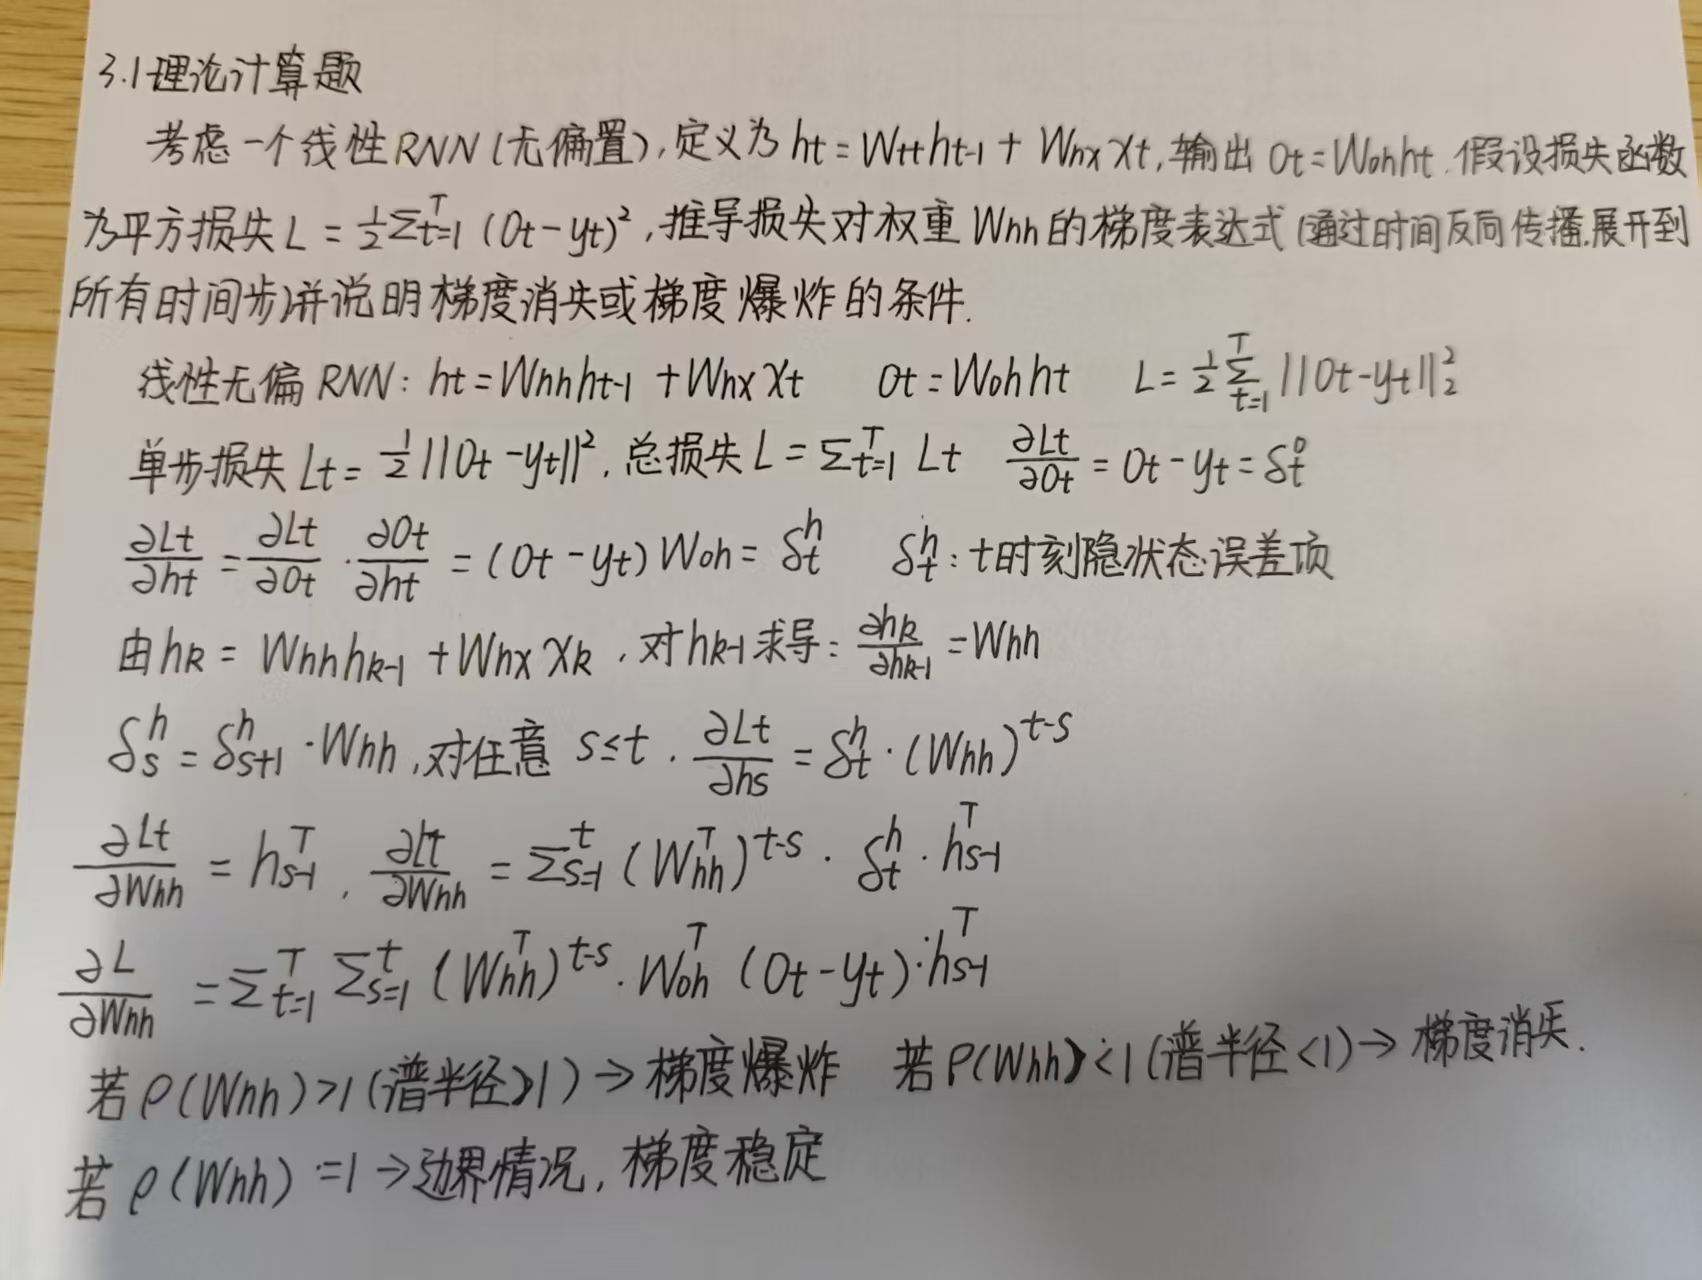

2.2 编程题  
&emsp;&emsp;实现一个简单的RNN单元的前向传播和单步反向传播（仅计算梯度，不更新）。给定输入x_t（形状（batch_size,input_size））、上一隐藏状态h_prev（形状（batch_size,hidden_size）），以及权重W_hx,W_hh,b_h，计算当前隐藏状态h_t。同时实现反向传播，已知上游梯度dh_next（即损失对h_t的梯度），计算dx_t,dh_prev,dW_hx,dW_hh,db_h（使用tanh激活函数）。

In [7]:
import numpy as np

# 定义输入数据和参数
# batch_size = 2
# input_size = 3
# hidden_size = 2

x_t = np.array([[1, 2, 3],
                [4, 5, 6]])

h_prev = np.array([[0.1, 0.2],
                   [0.3, 0.4]])

W_hx = np.array([[0.1, 0.2],
                 [0.3, 0.4],
                 [0.5, 0.6]])

W_hh = np.array([[0.7, 0.8],
                 [0.9, 1.0]])

b_h = np.array([0.1, 0.2])

print("输入 x_t：")
print(x_t)

print("\n上一隐藏状态 h_prev：")
print(h_prev)

print("\n输入权重 W_hx：")
print(W_hx)

print("\n隐藏层权重 W_hh：")
print(W_hh)

print("\n偏置 b_h：")
print(b_h)

输入 x_t：
[[1 2 3]
 [4 5 6]]

上一隐藏状态 h_prev：
[[0.1 0.2]
 [0.3 0.4]]

输入权重 W_hx：
[[0.1 0.2]
 [0.3 0.4]
 [0.5 0.6]]

隐藏层权重 W_hh：
[[0.7 0.8]
 [0.9 1. ]]

偏置 b_h：
[0.1 0.2]


In [8]:
# 前向传播
z = np.dot(x_t, W_hx) + np.dot(h_prev, W_hh) + b_h

h_t = np.tanh(z)

print("线性组合 z：")
print(z)

print("\n当前隐藏状态 h_t：")
print(h_t)

线性组合 z：
[[2.55 3.28]
 [5.57 7.24]]

当前隐藏状态 h_t：
[[0.9878804  0.99717223]
 [0.99997096 0.99999897]]


In [9]:
#定义上游梯度
dh_next = np.array([[1.0, 1.0],
                    [1.0, 1.0]])

print("上游梯度 dh_next：")
print(dh_next)

上游梯度 dh_next：
[[1. 1.]
 [1. 1.]]


In [10]:
# 计算tanh的梯度
dz = dh_next * (1 - h_t**2)

print("dz = dh_next × (1-h_t²)：")
print(dz)

dz = dh_next × (1-h_t²)：
[[2.40923212e-02 5.64753898e-03]
 [5.80773580e-05 2.05814253e-06]]


In [11]:
# 计算dx_t、dh_prev、dW_hx、dW_hh、db_h
dx_t = np.dot(dz, W_hx.T)

print("dx_t：")
print(dx_t)

dh_prev = np.dot(dz, W_hh.T)

print("dh_prev：")
print(dh_prev)

dW_hx = np.dot(x_t.T, dz)

print("dW_hx：")
print(dW_hx)

dW_hh = np.dot(h_prev.T, dz)

print("dW_hh：")
print(dW_hh)

db_h = np.sum(dz, axis=0)

print("db_h：")
print(db_h)

dx_t：
[[3.53873992e-03 9.48671195e-03 1.54346840e-02]
 [6.21936430e-06 1.82464644e-05 3.02735645e-05]]
dh_prev：
[[2.13826560e-02 2.73306281e-02]
 [4.23006646e-05 5.43277647e-05]]
dW_hx：
[[0.02432463 0.00565577]
 [0.04847503 0.01130537]
 [0.07262543 0.01695497]]
dW_hh：
[[0.00242666 0.00056537]
 [0.0048417  0.00113033]]
db_h：
[0.0241504 0.0056496]


In [12]:
# 定义forward和backward函数
def rnn_forward(x_t, h_prev, W_hx, W_hh, b_h):
    z = np.dot(x_t, W_hx) + np.dot(h_prev, W_hh) + b_h
    h_t = np.tanh(z)

    cache = (x_t, h_prev, W_hx, W_hh, h_t)

    return h_t, cache


def rnn_backward(dh_next, cache):
    x_t, h_prev, W_hx, W_hh, h_t = cache

    dz = dh_next * (1 - h_t**2)

    dx_t = np.dot(dz, W_hx.T)

    dh_prev = np.dot(dz, W_hh.T)

    dW_hx = np.dot(x_t.T, dz)

    dW_hh = np.dot(h_prev.T, dz)

    db_h = np.sum(dz, axis=0)

    return dx_t, dh_prev, dW_hx, dW_hh, db_h

三、高级循环神经网络

3.1 理论计算题

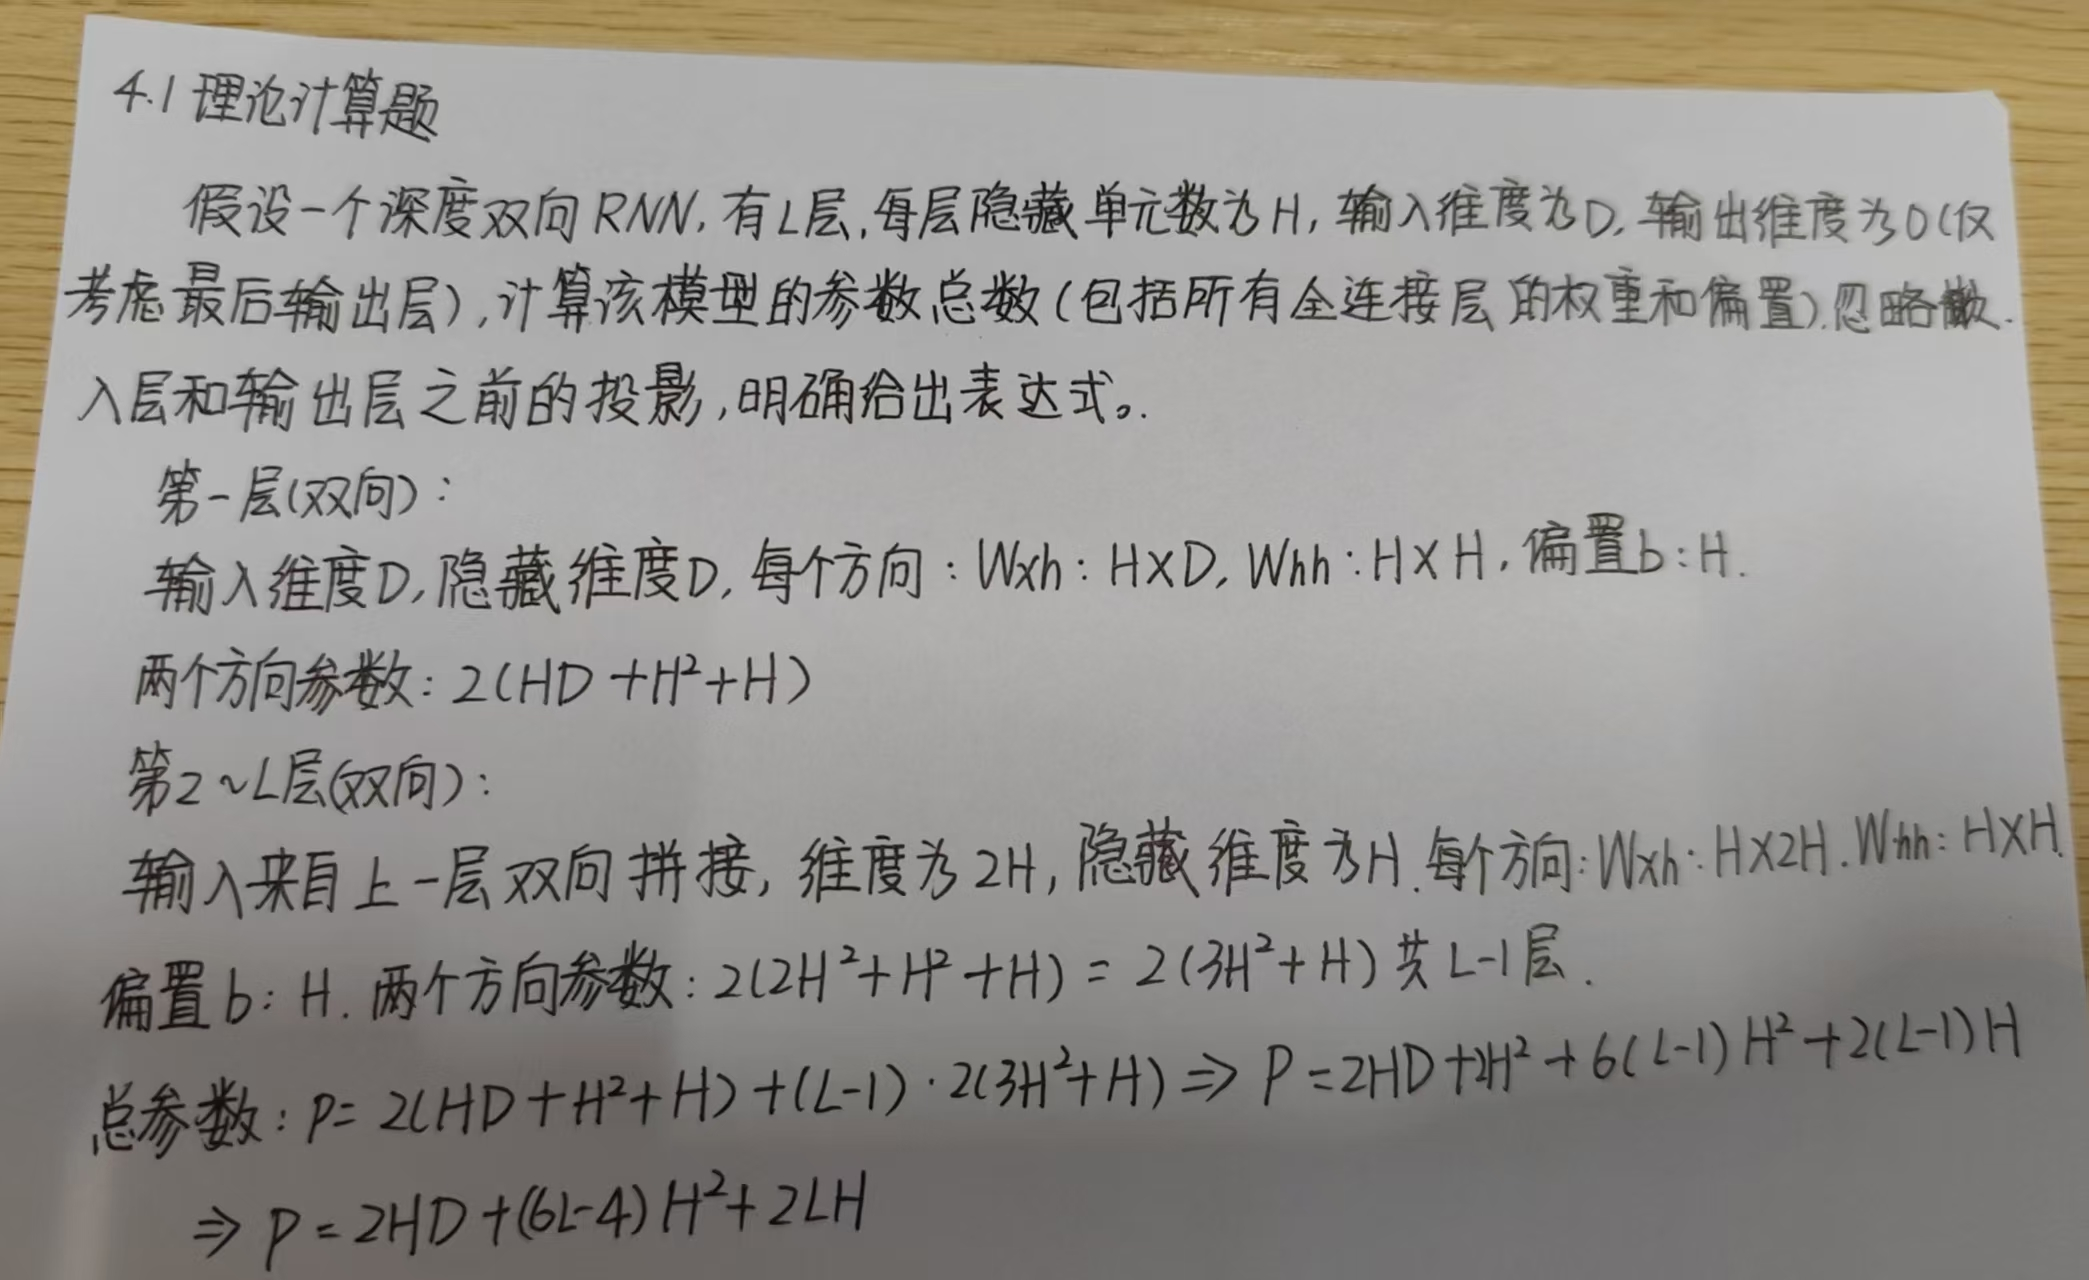

3.2 编程题  
&emsp;&emsp;实现一个双向RNN编码器，接收序列X（形状（seq_len,batch,input_dim）），使用torch.nn.RNN或手动实现。要求返回每个时间步的拼接后的前向和后向隐藏状态（形状（seq_len,batch,2*hidden_dim）），以及最终时间步的拼接隐藏状态（作为序列表示）。

In [2]:
import torch
import torch.nn as nn

# 定义输入序列X
torch.manual_seed(0)

seq_len = 4
batch_size = 2
input_dim = 3
hidden_dim = 5

X = torch.randn(seq_len, batch_size, input_dim)

print("输入序列 X：")
print(X)

print("\nX 的形状：")
print(X.shape)

输入序列 X：
tensor([[[-1.1258, -1.1524, -0.2506],
         [-0.4339,  0.8487,  0.6920]],

        [[-0.3160, -2.1152,  0.4681],
         [-0.1577,  1.4437,  0.2660]],

        [[ 0.1665,  0.8744, -0.1435],
         [-0.1116,  0.9318,  1.2590]],

        [[ 2.0050,  0.0537,  0.6181],
         [-0.4128, -0.8411, -2.3160]]])

X 的形状：
torch.Size([4, 2, 3])


In [3]:
# 建立双向RNN
rnn = nn.RNN(
    input_size=input_dim,
    hidden_size=hidden_dim,
    bidirectional=True
)

print("双向RNN建立成功")
print(rnn)

双向RNN建立成功
RNN(3, 5, bidirectional=True)


In [4]:
# 前向传播
output, h_n = rnn(X)

print("每个时间步的隐藏状态 output：")
print(output)

print("\noutput 的形状：")
print(output.shape)

每个时间步的隐藏状态 output：
tensor([[[-2.6674e-01,  8.4083e-01, -4.0933e-01, -6.0244e-01, -4.8214e-01,
          -6.0004e-01,  6.9633e-01, -5.2390e-01, -4.2221e-01,  7.8676e-01],
         [-5.6799e-01,  7.1005e-02,  9.7879e-02,  2.7594e-01,  5.8457e-04,
           4.8169e-01, -2.2943e-01, -5.4133e-01,  6.9203e-01,  3.0408e-02]],

        [[ 5.3789e-01,  7.7679e-01, -7.5672e-01, -8.3200e-01,  1.4169e-02,
          -2.7723e-01,  8.2411e-01, -5.7729e-01, -5.6879e-01,  5.2811e-01],
         [-6.4741e-01, -2.2499e-01,  4.9058e-01,  5.1050e-01, -2.7925e-01,
           4.5963e-01, -5.8087e-01, -3.4834e-01,  7.6570e-01,  4.5733e-01]],

        [[-2.5379e-01,  3.3181e-01,  1.1920e-01, -6.8526e-01,  3.7622e-01,
          -1.0432e-02, -2.9464e-01, -3.3882e-01,  3.9377e-01,  4.5072e-01],
         [-6.2014e-01, -4.7927e-01,  2.0095e-01,  7.5334e-01, -1.3352e-01,
           1.6974e-01, -3.8555e-01, -4.0368e-01,  1.2648e-01, -1.8606e-01]],

        [[-2.2782e-01, -6.0232e-01,  5.3444e-01, -6.9688e-02,  1.1236

In [6]:
# 最终隐藏状态
h_n.shape
print("最终隐藏状态 h_n：")
print(h_n)

print("\nh_n 的形状：")
print(h_n.shape)

最终隐藏状态 h_n：
tensor([[[-0.2278, -0.6023,  0.5344, -0.0697,  0.1124],
         [-0.5603,  0.8026,  0.4276, -0.7543, -0.8609]],

        [[-0.6000,  0.6963, -0.5239, -0.4222,  0.7868],
         [ 0.4817, -0.2294, -0.5413,  0.6920,  0.0304]]],
       grad_fn=<StackBackward0>)

h_n 的形状：
torch.Size([2, 2, 5])


In [7]:
# 拼接最终隐藏状态作为序列表示
sequence_representation = torch.cat((h_n[0], h_n[1]), dim=1)

print("序列表示：")
print(sequence_representation)

print("\n序列表示形状：")
print(sequence_representation.shape)

序列表示：
tensor([[-0.2278, -0.6023,  0.5344, -0.0697,  0.1124, -0.6000,  0.6963, -0.5239,
         -0.4222,  0.7868],
        [-0.5603,  0.8026,  0.4276, -0.7543, -0.8609,  0.4817, -0.2294, -0.5413,
          0.6920,  0.0304]], grad_fn=<CatBackward0>)

序列表示形状：
torch.Size([2, 10])


In [8]:
#封装成 BiRNNEncoder
class BiRNNEncoder(nn.Module):

    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_dim,
            hidden_size=hidden_dim,
            bidirectional=True
        )

    def forward(self, X):

        # output:
        # (seq_len, batch_size, 2*hidden_dim)
        output, h_n = self.rnn(X)

        # 拼接前向和后向最后隐藏状态
        sequence_representation = torch.cat(
            (h_n[0], h_n[1]),
            dim=1
        )

        return output, sequence_representation


print("BiRNNEncoder定义成功")

BiRNNEncoder定义成功


In [9]:
# 编码器
encoder = BiRNNEncoder(input_dim, hidden_dim)

outputs, seq_rep = encoder(X)

print("每个时间步拼接隐藏状态：")
print(outputs)

print("\noutputs 的形状：")
print(outputs.shape)

print("\n最终序列表示：")
print(seq_rep)

print("\nseq_rep 的形状：")
print(seq_rep.shape)

每个时间步拼接隐藏状态：
tensor([[[-0.6073,  0.3375, -0.0584,  0.6163,  0.2128, -0.8950,  0.6813,
          -0.3600,  0.1458,  0.6316],
         [ 0.5057, -0.5881, -0.0630, -0.6116,  0.7024, -0.2576,  0.1206,
          -0.1593,  0.4837, -0.0493]],

        [[-0.0502,  0.3389, -0.2961,  0.2572,  0.0461, -0.8084,  0.7883,
          -0.5737,  0.3818,  0.6919],
         [ 0.2283, -0.5456,  0.4225, -0.7599,  0.5395, -0.3390, -0.0555,
           0.4638,  0.3331, -0.0816]],

        [[ 0.5723, -0.4904,  0.0812, -0.6588,  0.6197, -0.1371,  0.2155,
           0.1887,  0.3874,  0.1088],
         [ 0.4879, -0.6197,  0.3642, -0.7824,  0.4945, -0.4258, -0.0548,
          -0.8582,  0.5952, -0.4426]],

        [[ 0.7018, -0.2416,  0.7862, -0.8325,  0.1483,  0.2501,  0.4139,
          -0.7349,  0.3546, -0.4216],
         [-0.9376,  0.6497,  0.8030,  0.8482, -0.5599,  0.0488,  0.8846,
           0.3239, -0.4369,  0.8863]]], grad_fn=<CatBackward0>)

outputs 的形状：
torch.Size([4, 2, 10])

最终序列表示：
tensor([[ 0.7018, -0.

四、嵌入向量

4.1 理论计算题

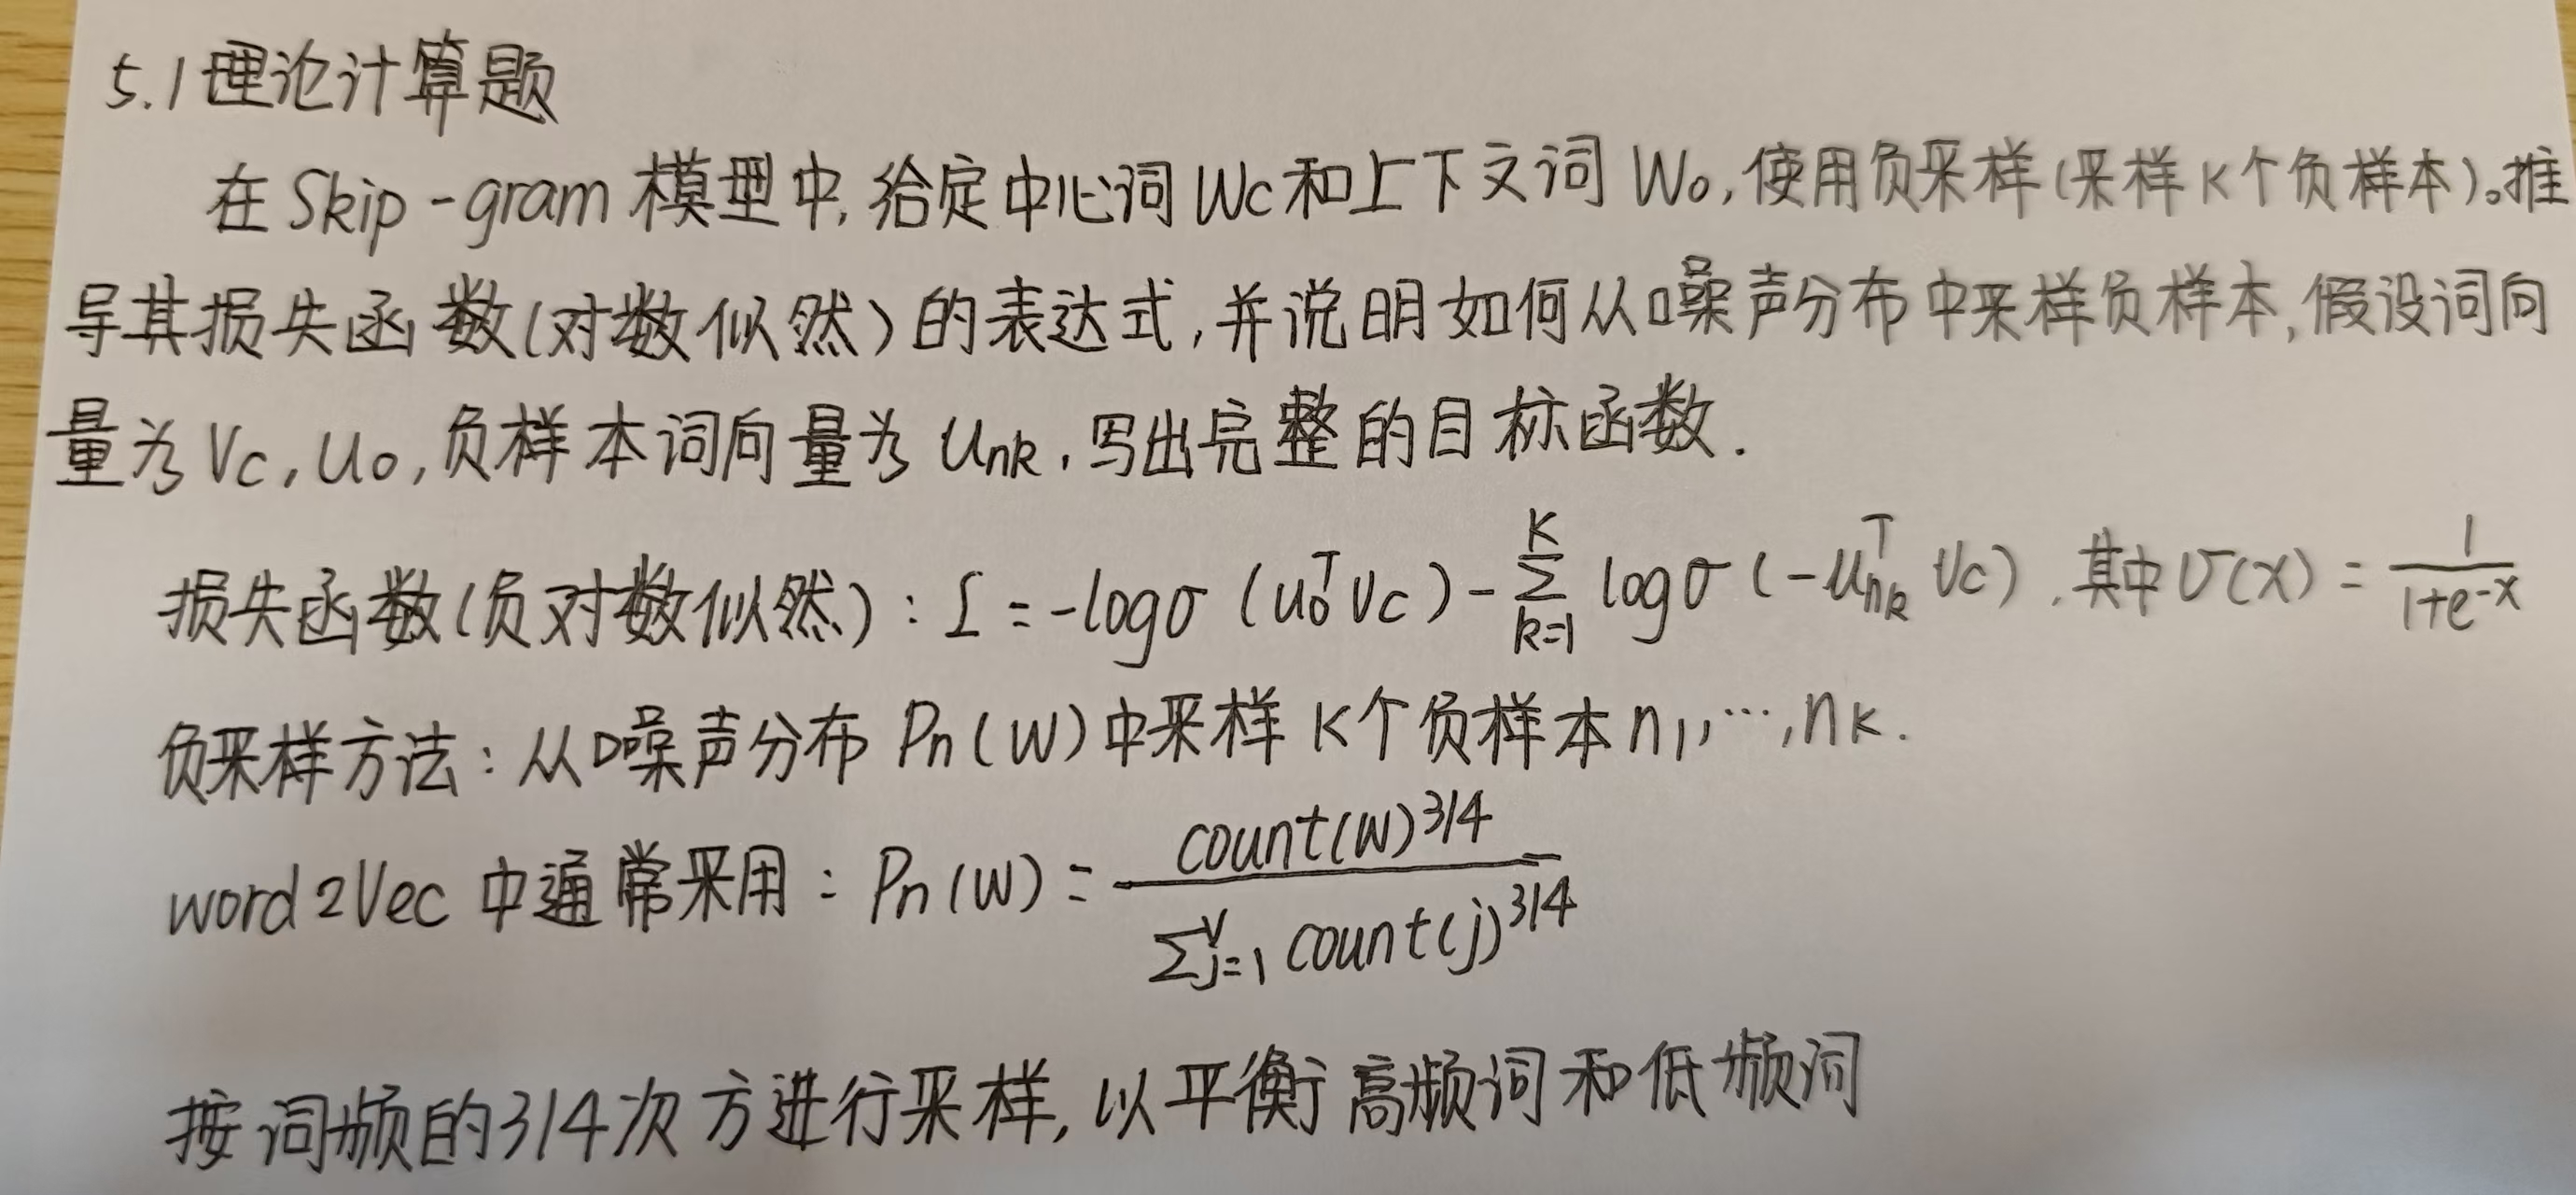

4.2 编程题  
&emsp;&emsp;实现CBOW模型的前向传播和损失计算（不使用负采样，仅用完整softmax）。给定一批上下文词的索引列表（每个样本有context_size个上下文词），词汇表大小V，嵌入维度d。输入权重矩阵W（形状（V,d））和输出权重矩阵W_out（形状（d,W））。计算平均上下文向量作为隐藏层，然后计算输出概率分布，并计算交叉熵损失（目标为中心词索引）。返回损失值。

In [2]:
import numpy as np

# 定义参数
np.random.seed(0)

V = 6
d = 4

# 输入权重矩阵
W = np.random.randn(V, d)

# 输出权重矩阵
W_out = np.random.randn(d, V)

print("输入权重矩阵 W：")
print(W)

print("\nW 的形状：")
print(W.shape)

print("\n输出权重矩阵 W_out：")
print(W_out)

print("\nW_out 的形状：")
print(W_out.shape)

输入权重矩阵 W：
[[ 1.76405235  0.40015721  0.97873798  2.2408932 ]
 [ 1.86755799 -0.97727788  0.95008842 -0.15135721]
 [-0.10321885  0.4105985   0.14404357  1.45427351]
 [ 0.76103773  0.12167502  0.44386323  0.33367433]
 [ 1.49407907 -0.20515826  0.3130677  -0.85409574]
 [-2.55298982  0.6536186   0.8644362  -0.74216502]]

W 的形状：
(6, 4)

输出权重矩阵 W_out：
[[ 2.26975462 -1.45436567  0.04575852 -0.18718385  1.53277921  1.46935877]
 [ 0.15494743  0.37816252 -0.88778575 -1.98079647 -0.34791215  0.15634897]
 [ 1.23029068  1.20237985 -0.38732682 -0.30230275 -1.04855297 -1.42001794]
 [-1.70627019  1.9507754  -0.50965218 -0.4380743  -1.25279536  0.77749036]]

W_out 的形状：
(4, 6)


In [3]:
# 给定上下文词和中心词
context_words = np.array([
    [0, 2],
    [3, 5]
])

target_words = np.array([1, 4])

print("上下文词索引：")
print(context_words)

print("\n目标中心词索引：")
print(target_words)

上下文词索引：
[[0 2]
 [3 5]]

目标中心词索引：
[1 4]


In [4]:
# 查看上下文词向量
context_vectors = W[context_words]

print("上下文词对应的词向量：")
print(context_vectors)

print("\n形状：")
print(context_vectors.shape)

上下文词对应的词向量：
[[[ 1.76405235  0.40015721  0.97873798  2.2408932 ]
  [-0.10321885  0.4105985   0.14404357  1.45427351]]

 [[ 0.76103773  0.12167502  0.44386323  0.33367433]
  [-2.55298982  0.6536186   0.8644362  -0.74216502]]]

形状：
(2, 2, 4)


In [5]:
# 计算隐藏层
hidden = np.mean(context_vectors, axis=1)

print("隐藏层向量 h：")
print(hidden)

print("\nh 的形状：")
print(hidden.shape)

隐藏层向量 h：
[[ 0.83041675  0.40537786  0.56139078  1.84758335]
 [-0.89597605  0.38764681  0.65414972 -0.20424535]]

h 的形状：
(2, 4)


In [6]:
# 计算输出层得分
scores = np.dot(hidden, W_out)

print("输出层得分 scores：")
print(scores)

print("\nscores 的形状：")
print(scores.shape)

输出层得分 scores：
[[-0.51414805  3.2247942  -1.48095663 -1.93750039 -1.77148217  1.9228538 ]
 [-0.82028885  1.83776994 -0.53442149 -0.7084138  -1.93823349 -2.3436052 ]]

scores 的形状：
(2, 6)


In [8]:
# 计算Softmax概率
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

probabilities = softmax(scores)

print("输出概率分布：")
print(probabilities)

print("\n概率矩阵形状：")
print(probabilities.shape)

输出概率分布：
[[0.01805126 0.75911845 0.0068648  0.00434864 0.00513398 0.20648286]
 [0.05475614 0.78129149 0.07287582 0.0612378  0.01790258 0.01193617]]

概率矩阵形状：
(2, 6)


In [9]:
# 取出目标词概率
target_probs = probabilities[
    np.arange(len(target_words)),
    target_words
]

print("目标词概率：")
print(target_probs)

目标词概率：
[0.75911845 0.01790258]


In [10]:
# 计算交叉熵损失
loss = -np.mean(np.log(target_probs))

print("交叉熵损失：")
print(loss)

交叉熵损失：
2.149203924859208


In [11]:
def cbow_forward(context_words,
                 target_words,
                 W,
                 W_out):

    # 查词向量
    context_vectors = W[context_words]

    # 平均得到隐藏层
    hidden = np.mean(context_vectors, axis=1)

    # 输出层
    scores = np.dot(hidden, W_out)

    # softmax
    exp_scores = np.exp(
        scores - np.max(scores, axis=1, keepdims=True)
    )

    probabilities = exp_scores / np.sum(
        exp_scores,
        axis=1,
        keepdims=True
    )

    # 目标词概率
    target_probs = probabilities[
        np.arange(len(target_words)),
        target_words
    ]

    # 交叉熵损失
    loss = -np.mean(np.log(target_probs))

    return loss

In [12]:
loss = cbow_forward(
    context_words,
    target_words,
    W,
    W_out
)

print("最终损失值：")
print(loss)

最终损失值：
2.149203924859208


五、注意力机制

5.1 理论计算题

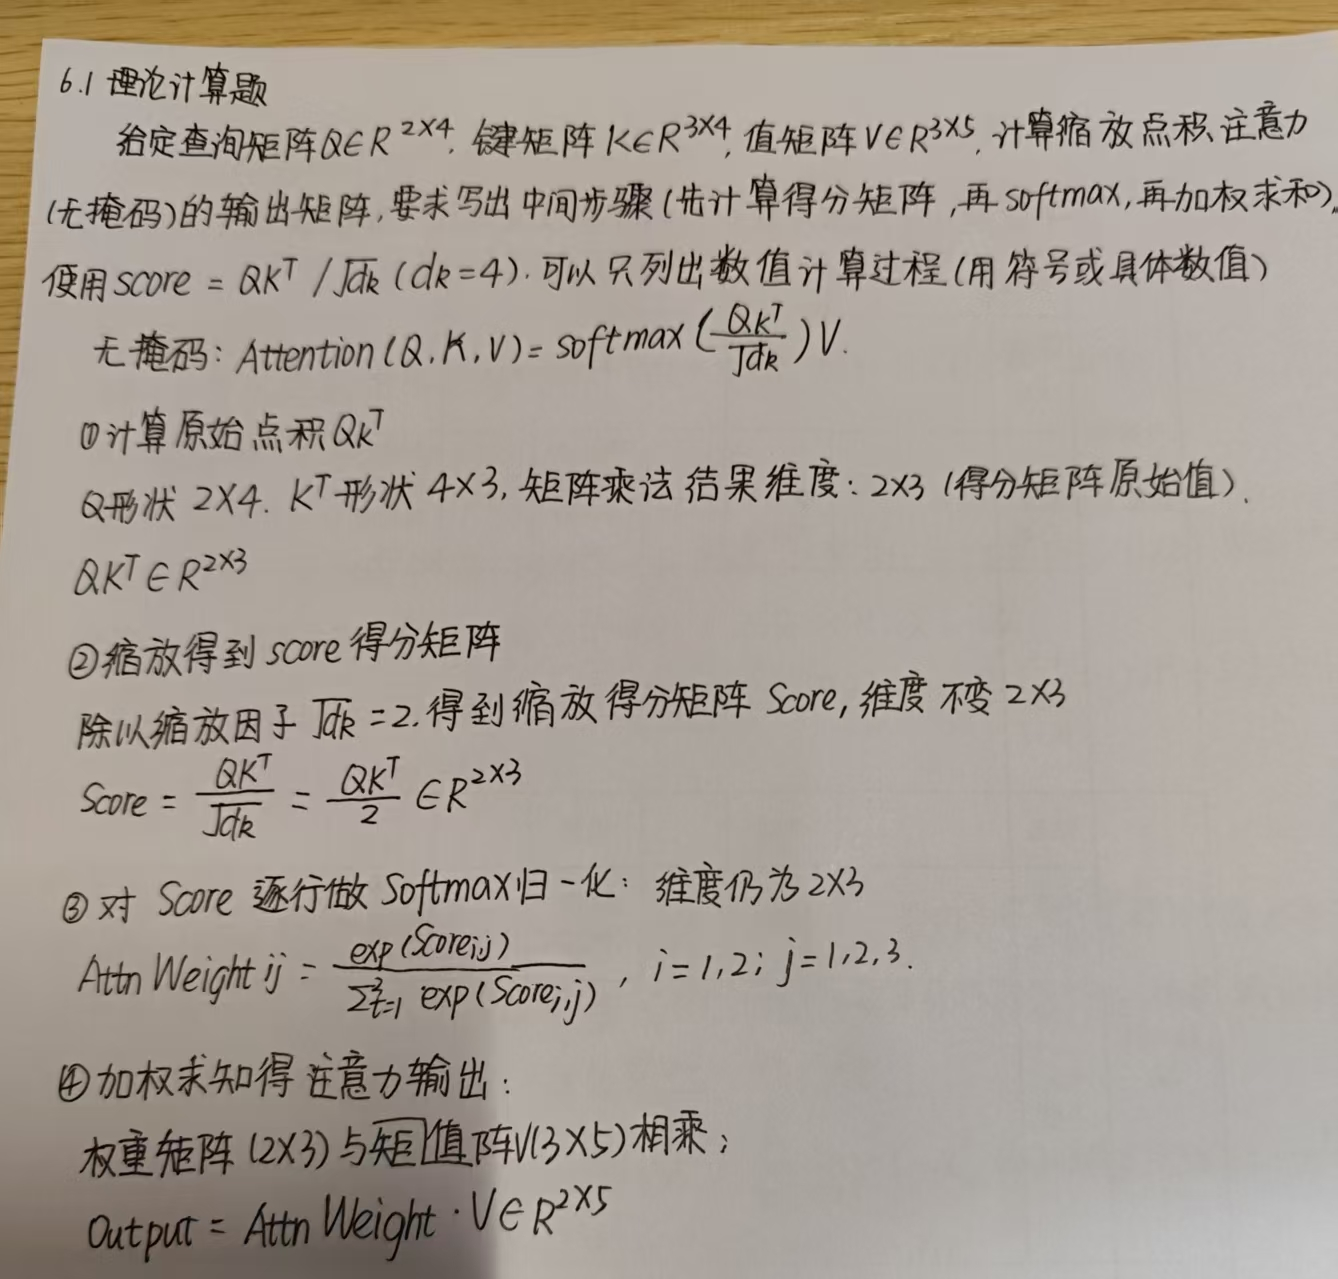

5.2 编程题  
&emsp;&emsp;实现多头注意力（Multi-Head Attention）的前向传播，假设num_heads=2,d_model=4。给定输入X（形状（seq_len,batch,d_model）），分别线性投影得到Q，K，V（每个头的维度d_k=d_v=d_model/num_heads）。对每个头计算缩放点积注意力，然后将所有头的输出拼接并经过最终线性层。返回输出（形状与输入相同）。

In [13]:
import torch
import math

# 定义输入X
torch.manual_seed(0)

seq_len = 3
batch_size = 2
d_model = 4
num_heads = 2
d_k = d_model // num_heads

X = torch.randn(seq_len, batch_size, d_model)

print("输入 X：")
print(X)

print("\nX的形状：")
print(X.shape)

输入 X：
tensor([[[-1.1258, -1.1524, -0.2506, -0.4339],
         [ 0.8487,  0.6920, -0.3160, -2.1152]],

        [[ 0.4681, -0.1577,  1.4437,  0.2660],
         [ 0.1665,  0.8744, -0.1435, -0.1116]],

        [[ 0.9318,  1.2590,  2.0050,  0.0537],
         [ 0.6181, -0.4128, -0.8411, -2.3160]]])

X的形状：
torch.Size([3, 2, 4])


In [14]:
# 初始化权重矩阵
W_Q = torch.randn(d_model, d_model)
W_K = torch.randn(d_model, d_model)
W_V = torch.randn(d_model, d_model)
W_O = torch.randn(d_model, d_model)

print("W_Q形状：", W_Q.shape)
print("W_K形状：", W_K.shape)
print("W_V形状：", W_V.shape)
print("W_O形状：", W_O.shape)

W_Q形状： torch.Size([4, 4])
W_K形状： torch.Size([4, 4])
W_V形状： torch.Size([4, 4])
W_O形状： torch.Size([4, 4])


In [15]:
# 线性投影得到Q、K、V
Q = torch.matmul(X, W_Q)
K = torch.matmul(X, W_K)
V = torch.matmul(X, W_V)

print("Q的形状：", Q.shape)
print("K的形状：", K.shape)
print("V的形状：", V.shape)

Q的形状： torch.Size([3, 2, 4])
K的形状： torch.Size([3, 2, 4])
V的形状： torch.Size([3, 2, 4])


In [16]:
# 划分成两个头
Q = Q.view(seq_len, batch_size, num_heads, d_k)
K = K.view(seq_len, batch_size, num_heads, d_k)
V = V.view(seq_len, batch_size, num_heads, d_k)

print("Q的形状：")
print(Q.shape)

Q的形状：
torch.Size([3, 2, 2, 2])


In [17]:
# 交换维度
Q = Q.permute(2,1,0,3)
K = K.permute(2,1,0,3)
V = V.permute(2,1,0,3)

print("Q的新形状：")
print(Q.shape)

Q的新形状：
torch.Size([2, 2, 3, 2])


In [18]:
# 计算Attention Score
scores = torch.matmul(
    Q,
    K.transpose(-2,-1)
) / math.sqrt(d_k)

print("Attention Scores：")
print(scores)

print("\nscores形状：")
print(scores.shape)

Attention Scores：
tensor([[[[-1.4916, -0.8842,  1.8450],
          [ 0.2445, -2.4577, -2.2068],
          [ 1.3051, -2.9772, -4.3590]],

         [[ 0.8647, -0.1630,  1.5107],
          [-1.4015, -0.8181, -0.6484],
          [ 0.7094,  0.4942,  0.1950]]],


        [[[-0.9052,  0.7658,  2.4667],
          [ 0.4636,  0.2910, -0.7446],
          [ 0.6324, -0.1682, -1.4446]],

         [[ 3.9853,  2.5374,  0.6629],
          [-1.6433,  0.1391, -1.9193],
          [ 6.4936,  2.9458,  2.7306]]]])

scores形状：
torch.Size([2, 2, 3, 3])


In [19]:
# Softmax得到注意力权重
attention_weights = torch.softmax(scores, dim=-1)

print("Attention Weights：")
print(attention_weights)

print("\n形状：")
print(attention_weights.shape)

Attention Weights：
tensor([[[[0.0323, 0.0593, 0.9084],
          [0.8671, 0.0582, 0.0747],
          [0.9830, 0.0136, 0.0034]],

         [[0.3062, 0.1096, 0.5842],
          [0.2034, 0.3646, 0.4320],
          [0.4159, 0.3354, 0.2487]]],


        [[[0.0282, 0.1500, 0.8218],
          [0.4673, 0.3932, 0.1396],
          [0.6352, 0.2852, 0.0796]],

         [[0.7867, 0.1849, 0.0284],
          [0.1298, 0.7717, 0.0985],
          [0.9506, 0.0274, 0.0221]]]])

形状：
torch.Size([2, 2, 3, 3])


In [20]:
# 计算每个头的输出
head_outputs = torch.matmul(
    attention_weights,
    V
)

print("每个头输出：")
print(head_outputs)

print("\nhead_outputs形状：")
print(head_outputs.shape)

每个头输出：
tensor([[[[ 0.6137, -0.0385],
          [-0.0248, -1.6197],
          [-0.1380, -1.8370]],

         [[ 2.2025,  1.3958],
          [ 1.3856,  1.0448],
          [ 1.3035,  1.0383]]],


        [[[-2.6215,  1.9112],
          [-1.1220, -0.5127],
          [-0.9072, -1.2673]],

         [[-0.1457,  0.5226],
          [-0.2703,  0.2711],
          [-0.0931,  0.5827]]]])

head_outputs形状：
torch.Size([2, 2, 3, 2])


In [22]:
# 拼接所有头
head_outputs = head_outputs.permute(2,1,0,3)

concat_output = head_outputs.contiguous().view(
    seq_len,
    batch_size,
    d_model
)

print("拼接后的输出：")
print(concat_output)

print("\nconcat_output形状：")
print(concat_output.shape)

拼接后的输出：
tensor([[[ 0.6137, -0.0385, -2.6215,  1.9112],
         [ 2.2025,  1.3958, -0.1457,  0.5226]],

        [[-0.0248, -1.6197, -1.1220, -0.5127],
         [ 1.3856,  1.0448, -0.2703,  0.2711]],

        [[-0.1380, -1.8370, -0.9072, -1.2673],
         [ 1.3035,  1.0383, -0.0931,  0.5827]]])

concat_output形状：
torch.Size([3, 2, 4])


In [23]:
# 经过最终线性层
output = torch.matmul(
    concat_output,
    W_O
)

print("最终输出：")
print(output)

print("\n最终输出形状：")
print(output.shape)

最终输出：
tensor([[[ 3.2493, -1.7657, -1.6252, -3.1561],
         [ 2.7353, -0.6928,  2.4570,  0.2529]],

        [[-1.2345, -0.1380, -1.1313, -1.3512],
         [ 2.3397, -0.1551,  1.3639, -0.2295]],

        [[-1.7098,  0.6447, -1.1267, -1.2853],
         [ 1.9415, -0.5953,  1.4704,  0.1665]]])

最终输出形状：
torch.Size([3, 2, 4])


In [24]:
def multi_head_attention(X, W_Q, W_K, W_V, W_O, num_heads=2):

    seq_len, batch_size, d_model = X.shape
    d_k = d_model // num_heads

    # Q K V
    Q = torch.matmul(X, W_Q)
    K = torch.matmul(X, W_K)
    V = torch.matmul(X, W_V)

    # 分头
    Q = Q.view(seq_len,batch_size,num_heads,d_k)
    K = K.view(seq_len,batch_size,num_heads,d_k)
    V = V.view(seq_len,batch_size,num_heads,d_k)

    Q = Q.permute(2,1,0,3)
    K = K.permute(2,1,0,3)
    V = V.permute(2,1,0,3)

    # attention
    scores = torch.matmul(
        Q,
        K.transpose(-2,-1)
    ) / math.sqrt(d_k)

    weights = torch.softmax(scores, dim=-1)

    heads = torch.matmul(weights, V)

    # 拼接
    heads = heads.permute(2,1,0,3)

    concat_output = heads.contiguous().view(
        seq_len,
        batch_size,
        d_model
    )

    output = torch.matmul(
        concat_output,
        W_O
    )

    return output

In [25]:
output = multi_head_attention(
    X,
    W_Q,
    W_K,
    W_V,
    W_O,
    num_heads=2
)

print("最终输出：")
print(output)

print("\n输出形状：")
print(output.shape)

最终输出：
tensor([[[ 3.2493, -1.7657, -1.6252, -3.1561],
         [ 2.7353, -0.6928,  2.4570,  0.2529]],

        [[-1.2345, -0.1380, -1.1313, -1.3512],
         [ 2.3397, -0.1551,  1.3639, -0.2295]],

        [[-1.7098,  0.6447, -1.1267, -1.2853],
         [ 1.9415, -0.5953,  1.4704,  0.1665]]])

输出形状：
torch.Size([3, 2, 4])
